# Stock Market Direction Prediction Using PyCaret

# Developed by DEEPAK.M AI Generalist iPEC Solutions Private Limited Bangalore.
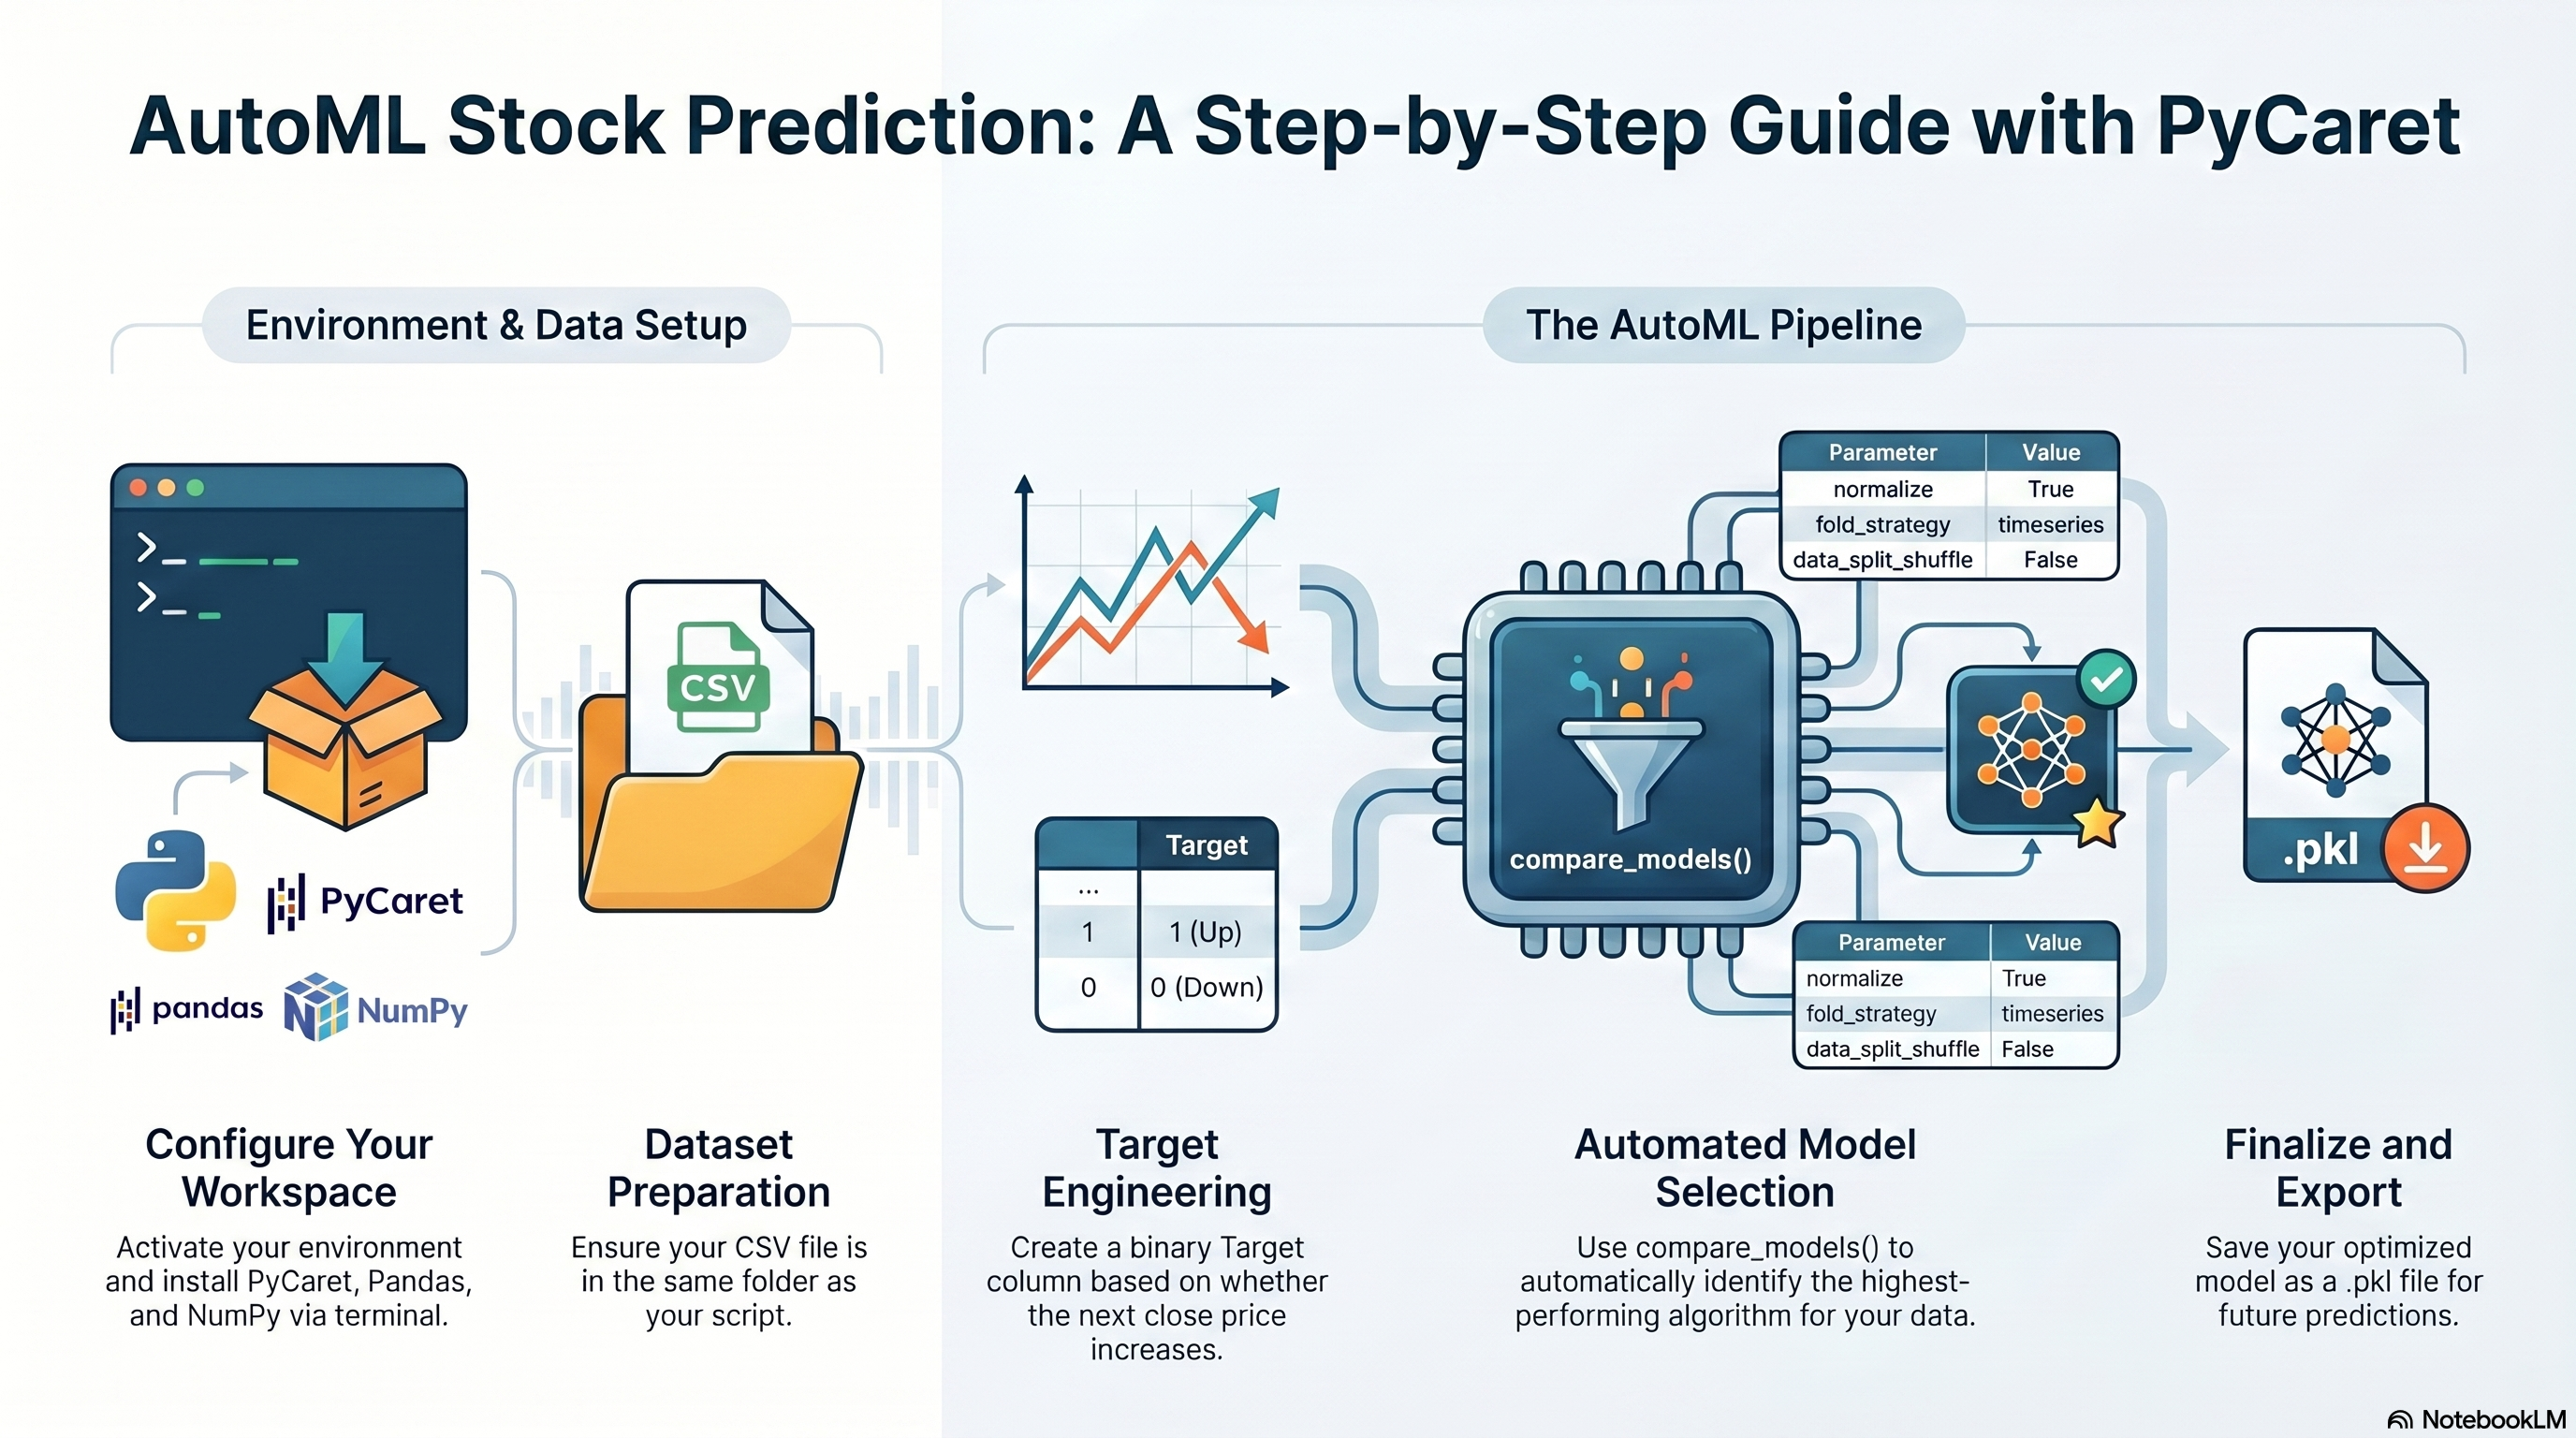

# 1.Import Libraries

In [22]:
import pandas as pd
from pycaret.classification import *

# 2.Load Dataset

In [23]:
import pandas as pd
df=pd.read_csv('stock_analysis.csv')
df.head()

,Stock,Date,Open,High,Low,Close,Volume,SMA_10,RSI,MACD,Bollinger_Upper,Bollinger_Lower,GDP_Growth,Inflation_Rate,Interest_Rate,Sentiment_Score,Next_Close,Target
0,AAPL,2010-01-04,445.627510,465.464143,431.513035,450.378213,2441288,301.310351,64.061774,2.449751,464.398638,438.231589,2.845199,1.505217,4.360374,-0.079418,445.714557,0
1,AAPL,2010-01-05,441.194244,449.726464,432.618124,437.397748,4714199,280.015623,52.032235,-3.726473,450.099041,431.018080,3.352677,1.516110,2.309996,0.511900,439.507357,1
2,AAPL,2010-01-07,395.417421,399.413060,385.055059,388.718345,3948217,323.131496,71.817441,-4.215862,396.010670,374.092744,3.471209,2.256823,0.984588,0.049279,387.335810,0
3,AAPL,2010-01-11,478.631057,501.639769,461.991967,484.401144,3637733,273.944016,67.133451,1.574418,496.399599,479.317188,2.962110,2.238436,1.754234,0.737874,476.642532,0
4,AAPL,2010-01-12,179.950904,183.900759,175.076588,181.516782,693492,237.354447,84.797294,1.552505,189.479672,171.610610,2.727858,2.378014,2.562107,-0.905092,182.863272,1


In [24]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50349 entries, 0 to 50348
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Stock            50349 non-null  object 
 1   Date             50349 non-null  object 
 2   Open             50349 non-null  float64
 3   High             50349 non-null  float64
 4   Low              50349 non-null  float64
 5   Close            50349 non-null  float64
 6   Volume           50349 non-null  int64  
 7   SMA_10           50349 non-null  float64
 8   RSI              50349 non-null  float64
 9   MACD             50349 non-null  float64
 10  Bollinger_Upper  50349 non-null  float64
 11  Bollinger_Lower  50349 non-null  float64
 12  GDP_Growth       50349 non-null  float64
 13  Inflation_Rate   50349 non-null  float64
 14  Interest_Rate    50349 non-null  float64
 15  Sentiment_Score  50349 non-null  float64
 16  Next_Close       50349 non-null  float64
 17  Target      

# 3.Checking Missing Values

In [25]:
print(df.isnull().sum())

Stock              0
Date               0
Open               0
High               0
Low                0
Close              0
Volume             0
SMA_10             0
RSI                0
MACD               0
Bollinger_Upper    0
Bollinger_Lower    0
GDP_Growth         0
Inflation_Rate     0
Interest_Rate      0
Sentiment_Score    0
Next_Close         0
Target             0
dtype: int64


# Train-Test Split Control

In [26]:
fold_strategy='timeseries'

# 4.Setup PyCaret

In [27]:
target='Target'

In [29]:
data_split_shuffle=False
fold_shuffle=False

In [31]:
s = setup(
    data=df,
    target='Target',
    session_id=123,
    normalize=True,
    remove_multicollinearity=True,
    feature_selection=True,
    fold_strategy='timeseries',
    data_split_shuffle=False,
    fold_shuffle=False,
    data_split_stratify=False
)

[LightGBM] [Info] Number of positive: 17699, number of negative: 17545
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003504 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2331
[LightGBM] [Info] Number of data points in the train set: 35244, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.502185 -> initscore=0.008739
[LightGBM] [Info] Start training from score 0.008739


,Description,Value
0,Session id,123
1,Target,Target
2,Target type,Binary
3,Original data shape,"(50349, 18)"
4,Transformed data shape,"(50349, 4)"
5,Transformed train set shape,"(35244, 4)"
6,Transformed test set shape,"(15105, 4)"
7,Numeric features,15
8,Categorical features,2
9,Preprocess,True


# 5.Compare Algorithms

In [8]:
best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
xgboost,Extreme Gradient Boosting,0.5100,0.5137,0.4916,0.5125,0.5016,0.0201,0.0202,6.2620
lightgbm,Light Gradient Boosting Machine,0.5088,0.5121,0.4629,0.5123,0.4857,0.0179,0.0180,3.1930
dt,Decision Tree Classifier,0.5087,0.5086,0.5106,0.5106,0.5106,0.0173,0.0173,3.0380
catboost,CatBoost Classifier,0.5081,0.5139,0.4792,0.5108,0.4942,0.0165,0.0165,30.4550
et,Extra Trees Classifier,0.5076,0.5123,0.4914,0.5100,0.5005,0.0153,0.0154,5.3470
lr,Logistic Regression,0.5075,0.5134,0.5617,0.5089,0.5333,0.0145,0.0144,6.2780
ridge,Ridge Classifier,0.5075,0.5134,0.5618,0.5089,0.5333,0.0145,0.0144,2.3280
lda,Linear Discriminant Analysis,0.5075,0.5134,0.5618,0.5089,0.5333,0.0145,0.0144,2.4050
gbc,Gradient Boosting Classifier,0.5073,0.5120,0.4009,0.5131,0.4466,0.0155,0.0162,8.4430
ada,Ada Boost Classifier,0.5070,0.5119,0.3974,0.5123,0.4436,0.0148,0.0156,4.5440


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

# 6.Train Best Model

In [9]:
final_model = finalize_model(best_model)

# 7.Check Accuracy

In [10]:
evaluate_model(final_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

# 8.Predict

In [11]:
predictions = predict_model(final_model)
print(predictions.head())

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.5049,0.5075,0.4983,0.5069,0.5026,0.0098,0.0098


      Stock        Date        Open        High         Low       Close  \
38966  MSFT  2179-01-26  140.444092  138.856628  137.516098  137.727631   
6690   AAPL  2139-07-22  300.238770  304.025635  289.369446  298.061432   
31137  MSFT  2026-04-01  270.240814  275.163055  256.166687  265.892181   
7175   AAPL  2149-01-17  230.558762  246.654068  231.524597  234.975510   
8903   AAPL  2181-11-05  501.822998  513.297363  489.028076  495.189575   

        Volume      SMA_10        RSI      MACD  Bollinger_Upper  \
38966  1707402  242.114426  76.879272 -0.343281       147.536163   
6690   4218306  290.541870  68.603531  4.200910       307.596527   
31137  2140503  299.747345  27.039587  3.173345       280.067657   
7175    976357  280.788208  21.092451 -3.488365       247.863724   
8903   1218699  408.848816  14.890698 -3.749748       501.036926   

       Bollinger_Lower  GDP_Growth  Inflation_Rate  Interest_Rate  \
38966       124.459595    3.262821        1.940641       1.153466   
66

# 9.Save model

In [12]:
save_model(final_model, 'stock_prediction_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Open', 'High', 'Low', 'Close',
                                              'Volume', 'SMA_10', 'RSI', 'MACD',
                                              'Bollinger_Upper',
                                              'Bollinger_Lower', 'GDP_Growth',
                                              'Inflation_Rate', 'Interest_Rate',
                                              'Sentiment_Score', 'Next_Close'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=Non...
                                gamma=0, gpu_id=-1, grow_policy='depthwise',
                                importance_type=None, interaction_constraints='',
        

In [13]:
loaded_model = load_model('stock_prediction_model')

Transformation Pipeline and Model Successfully Loaded


## Add Technical Indicators
RSI,
SMA,
EMA,
MACD,
Bollinger Bands.

In [16]:
#!pip install ta

In [19]:
from ta.momentum import RSIIndicator
from ta.trend import SMAIndicator
df['RSI'] = RSIIndicator(df['Close']).rsi()
df['SMA_10'] = SMAIndicator(df['Close'], window=10).sma_indicator()

# 10.Feature Importance

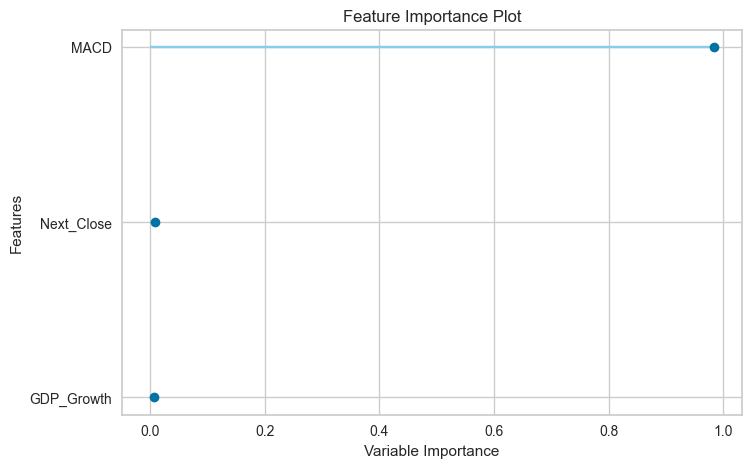

In [20]:
plot_model(final_model, plot='feature')